In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.weightstats import ttost_paired
from scipy.stats import spearmanr

# Load Data

In [2]:
data = pd.read_csv('./analysis.csv')

## Preprocessing

In [3]:
# Patient*innen oder Interessenvertretung
data['PatScoreArzt'] = data[['PatItem1Arzt', 'PatItem2Arzt', 'PatItem3Arzt','PatItem4Arzt']].sum(axis=1)
data['PatScoreKI'] = data[['PatItem1KI', 'PatItem2KI', 'PatItem3KI','PatItem4KI']].sum(axis=1)

# Experte 1: Sportwissenschaftlerin
data['Exp1ScoreArzt'] = data[['ExpItem1Arzt', 'ExpItem2Arzt', 'ExpItem3Arzt','ExpItem4Arzt']].sum(axis=1)
data['Exp1ScoreKI'] = data[['ExpItem1KI', 'ExpItem2KI', 'ExpItem3KI','ExpItem4KI']].sum(axis=1)

# Experte 2: Geriatrischer Oberarzt
data['Exp2ScoreArzt'] = data[['ExpItem1Arzt.1', 'ExpItem2Arzt.1', 'ExpItem3Arzt.1','ExpItem4Arzt.1']].sum(axis=1)
data['Exp2ScoreKI'] = data[['ExpItem1KI.1', 'ExpItem2KI.1', 'ExpItem3KI.1','ExpItem4KI.1']].sum(axis=1)


## Visual Inspection

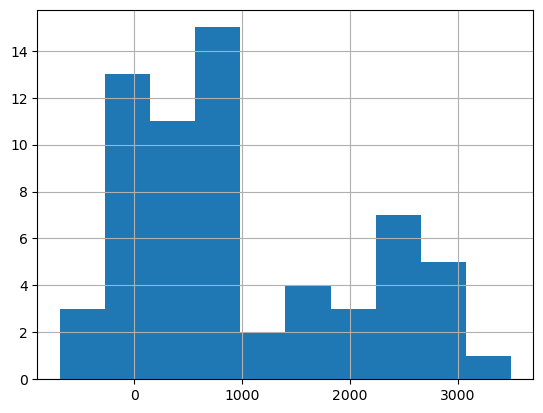

In [4]:
(data['human_translation_length'] - data['AI_translation_length']).hist();

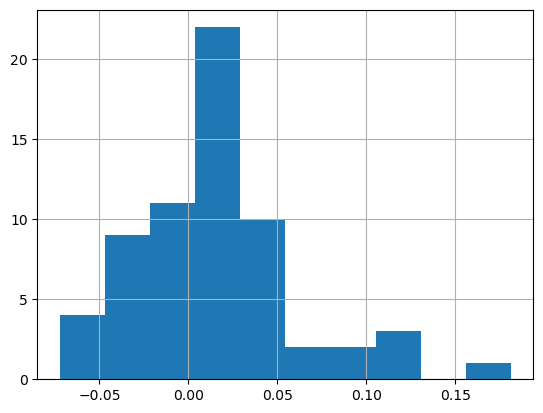

In [5]:
(data['cosine_similarity_original_vs_human'] - data['cosine_similarity_original_vs_AI']).hist();

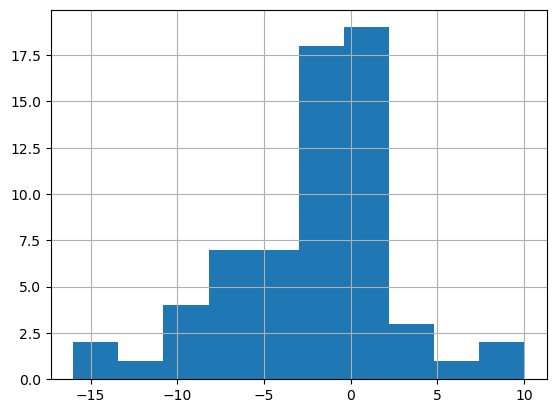

In [6]:
(data['PatScoreArzt'] - data['PatScoreKI']).hist();

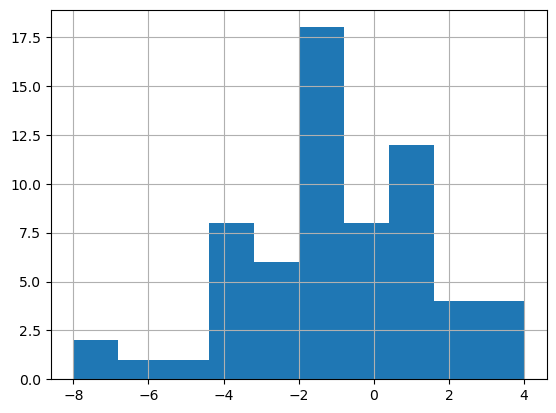

In [7]:
(data['Exp1ScoreArzt'] - data['Exp1ScoreKI']).hist();

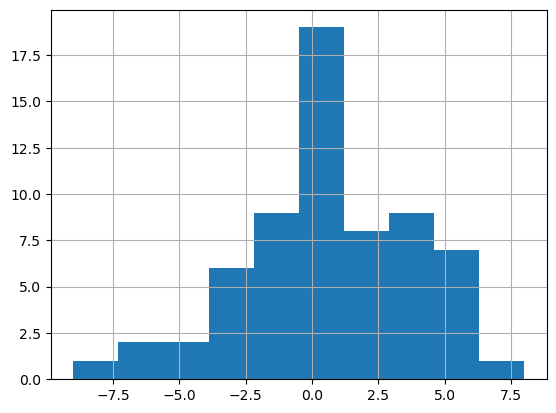

In [8]:
(data['Exp2ScoreArzt'] - data['Exp2ScoreKI']).hist();

# Statistical Analysis

## Lists

In [9]:
paired_t_tests = (
    ('Patients', 'PatScoreArzt', 'PatScoreKI'),
    ('Expert 1', 'Exp1ScoreArzt', 'Exp1ScoreKI'),
    ('Expert 2', 'Exp2ScoreArzt', 'Exp2ScoreKI')
)

wilcoxon_tests = (
    ('Patients', 'Clarity', 'PatItem1Arzt', 'PatItem1KI'),
    ('', 'Appropriateness of the content', 'PatItem2Arzt', 'PatItem2KI'),
    ('', 'Positivity of the content', 'PatItem3Arzt', 'PatItem3KI'),
    ('', 'Appropriateness of the language', 'PatItem4Arzt', 'PatItem4KI'),
    ('Expert 1', 'Clarity', 'ExpItem1Arzt', 'ExpItem1KI'),
    ('', 'Completness', 'ExpItem2Arzt', 'ExpItem2KI'),
    ('', 'Correctness', 'ExpItem3Arzt', 'ExpItem3KI'),
    ('', 'Appropriateness of the language', 'ExpItem4Arzt', 'ExpItem4KI'),
    ('Expert 2', 'Clarity', 'ExpItem1Arzt.1', 'ExpItem1KI.1'),
    ('', 'Completness', 'ExpItem2Arzt.1', 'ExpItem2KI.1'),
    ('', 'Correctness', 'ExpItem3Arzt.1', 'ExpItem3KI.1'),
    ('', 'Appropriateness of the language', 'ExpItem4Arzt.1', 'ExpItem4KI.1')
)

## Function

In [10]:
def t_test_for_equivalence(array1, array2, delta):
    """
    Perform a paired TOST (Two One-Sided Tests) equivalence test.

    Parameters
    ----------
    array1 : array-like
        First set of paired observations.
    array2 : array-like
        Second set of paired observations.
    delta : float
        Equivalence margin. Mean differences within [-delta, delta]
        are considered equivalent.

    Returns
    -------
    dict
        {
            'test': 'paired_t_test_for_equivalence',
            'mean_array1': float,
            'mean_array2': float,
            'std_array1': float,
            'std_array2': float,
            'p_value': float,
            'lower_test': (t_stat, p_value, df),
            'upper_test': (t_stat, p_value, df)
        }
    """
    pvalue, (t1, p1, df1), (t2, p2, df2) = ttost_paired(
        array1, array2,
        low=-delta,
        upp=delta
    )

    return {
        "test": "paired_t_test_for_equivalence",
        "mean_array1": np.mean(array1),
        "mean_array2": np.mean(array2),
        "std_array1": np.std(array1),
        "std_array2": np.std(array2),
        "p_value": pvalue,
        "lower_test": (t1, p1, df1),
        "upper_test": (t2, p2, df2),
    }
    

def paired_t_test(array1, array2):
    """
    Perform a paired t-test on two related samples.

    Parameters
    ----------
    array1 : array-like
        First set of observations.
    array2 : array-like
        Second set of paired observations.

    Returns
    -------
    dict
        {
            'test': 'paired_t_test',
            'mean_array1': float,
            'mean_array2': float,
            'std_array1': float,
            'std_array2': float,
            'statistic': float,
            'p_value': float
        }
    """
    stat, p = stats.ttest_rel(array1, array2)

    return {
        "test": "paired_t_test",
        "mean_array1": np.mean(array1),
        "mean_array2": np.mean(array2),
        "std_array1": np.std(array1),
        "std_array2": np.std(array2),
        "statistic": stat,
        "p_value": p
    }


def wilcoxon_test(array1, array2):
    """
    Perform a Wilcoxon signed-rank test for paired samples.

    Parameters
    ----------
    array1 : array-like
        First set of observations.
    array2 : array-like
        Second set of paired observations.

    Returns
    -------
    dict
        {
            'test': 'wilcoxon_signed_rank',
            'median_array1': float,
            'median_array2': float,
            'iqr_array1': tuple (Q1, Q3),
            'iqr_array2': tuple (Q1, Q3),
            'statistic': float,
            'p_value': float
        }
    """
    stat, p = stats.wilcoxon(array1, array2, zero_method='wilcox', mode='auto')
    
    return {
        "test": "wilcoxon_signed_rank",
        "median_array1": np.median(array1),
        "median_array2": np.median(array2),
        "iqr_array1": tuple(np.percentile(array1, [25, 75])),
        "iqr_array2": tuple(np.percentile(array2, [25, 75])),
        "statistic": stat,
        "p_value": p
    }

## Analysis

### Semantic Similarity

In [11]:
# Comparison
human = 'cosine_similarity_original_vs_human'
ai = 'cosine_similarity_original_vs_AI'

# Between human difference
human1 = data.loc[data['Experte']=='Thomas', human]
human2 = data.loc[data['Experte']=='Filippo', human]
delta = abs(human1.mean() - human2.mean())

# Paired t-test of equivalence 
results = t_test_for_equivalence(data[human], data[ai], delta)

# Print results
print(f"{'Mean value humans:':<25} {results['mean_array1']:>10.3f} ± {results['std_array1']:.3f}")
print(f"{'Mean value AI:':<25} {results['mean_array2']:>10.3f} ± {results['std_array2']:.3f}")
print(f"{'p-value:':<25} {results['p_value']:>10.3f}")

Mean value humans:             0.767 ± 0.041
Mean value AI:                 0.749 ± 0.041
p-value:                       0.018


### Main results

In [12]:
main_results = pd.DataFrame(columns=['Rater', 'Mean ± SD (human)', 'Mean ± SD (AI)', 'p-value'])

for rater, human, ai in paired_t_tests:
    results = paired_t_test(data[human], data[ai])
    mean_sd_human = f'{results['mean_array1']:.3f} ± {results['std_array1']:.3f}'
    mean_sd_ai = f'{results['mean_array2']:.3f} ± {results['std_array2']:.3f}'
    p_value = f'{results['p_value']:.3f}'
    row = {
        'Rater': rater,
        'Mean ± SD (human)': mean_sd_human,
        'Mean ± SD (AI)': mean_sd_ai,
        'p-value': str(p_value)
    }
    main_results = pd.concat([main_results, pd.DataFrame([row])], ignore_index=True)

main_results.to_csv('./main_results.csv', index=False)
main_results

,Rater,Mean ± SD (human),Mean ± SD (AI),p-value
0,Patients,14.953 ± 4.241,17.266 ± 3.099,0.000
1,Expert 1,16.766 ± 1.910,17.891 ± 1.404,0.001
2,Expert 2,14.516 ± 2.456,13.922 ± 2.320,0.145


### Individual items

In [13]:
individual_items = pd.DataFrame(columns=['Rater', 'Item', 'Median (IQR) human','Median (IQR) AI', 'p-value'])

for rater, item, human, ai in wilcoxon_tests:
    results = wilcoxon_test(data[human], data[ai])
    median_iqr_human = f'{int(results['median_array1'])} {str(results['iqr_array1'])}'
    median_iqr_ai = f'{int(results['median_array2'])} {str(results['iqr_array2'])}'
    p_value = f'{results['p_value']:.3f}'
    row = {
        'Rater': rater,
        'Item': item,
        'Median (IQR) human': median_iqr_human,
        'Median (IQR) AI': median_iqr_ai,
        'p-value': str(p_value)
    }
    individual_items = pd.concat([individual_items, pd.DataFrame([row])], ignore_index=True)

individual_items.to_csv('./individual_items.csv', index=False)
individual_items

,Rater,Item,Median (IQR) human,Median (IQR) AI,p-value
0,Patients,Clarity,"4 (3.0, 5.0)","5 (4.0, 5.0)",0.001
1,,Appropriateness of the content,"4 (3.0, 5.0)","5 (4.0, 5.0)",0.001
2,,Positivity of the content,"4 (3.0, 5.0)","5 (4.0, 5.0)",0.011
3,,Appropriateness of the language,"4 (3.0, 5.0)","5 (4.0, 5.0)",0.001
4,Expert 1,Clarity,"4 (4.0, 5.0)","5 (5.0, 5.0)",0.000
5,,Completness,"5 (4.0, 5.0)","4 (4.0, 5.0)",0.001
6,,Correctness,"4 (4.0, 4.0)","4 (4.0, 5.0)",0.010
7,,Appropriateness of the language,"4 (4.0, 5.0)","5 (4.0, 5.0)",0.000
8,Expert 2,Clarity,"4 (3.0, 4.0)","4 (3.75, 4.0)",0.060
9,,Completness,"4 (3.0, 4.0)","3 (2.0, 4.0)",0.000


## Text Length

In [14]:
human = 'human_translation_length'
ai = 'AI_translation_length'

results = paired_t_test(data[human], data[ai])
print(f"{'Mean value humans:':<25} {results['mean_array1']:>10.3f}")
print(f"{'Mean value AI:':<25} {results['mean_array2']:>10.3f}")
print(f"{'p-value:':<25} {results['p_value']:>10.3f}")
print()

Mean value humans:          2509.625
Mean value AI:              1522.797
p-value:                       0.000



In [15]:
x = np.concatenate((data[ai].values, data[human].values))
y = np.concatenate((data['ExpItem2KI'].values, data['ExpItem2Arzt'].values))
corr, p_value = spearmanr(x, y)
print(f"{'Spearman correlation:':<25} {corr:>10.3f}")
print(f"{'p-value:':<25} {p_value:>10.3f}")

Spearman correlation:          0.291
p-value:                       0.001


# Export Data

In [16]:
data.to_csv('./GISelA.csv', index=False)
data.to_excel('./GISelA.xlsx', index=False)